In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [ ]:
SEED = 123
from src.utils import seed_everything
seed_everything(SEED)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829
Kurtosis: 6.5363


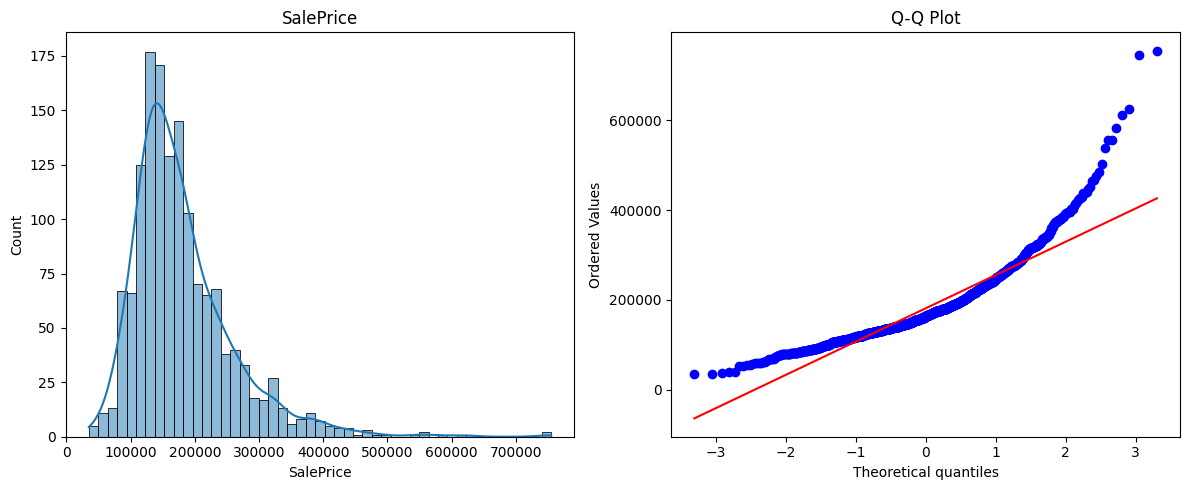

In [6]:
# SalePriceの基本統計
print(train_df['SalePrice'].describe())
print("\nSkewness: {:.4f}".format(train_df['SalePrice'].skew()))
print("Kurtosis: {:.4f}".format(train_df['SalePrice'].kurt()))

# 分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

stats.probplot(train_df['SalePrice'], plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()



*   Skewness 1.88、Kurtosis 6.54 → 右に強く歪んでいて、裾が重い

*   ヒストグラムが右裾に伸びてる → 高額物件が少数だけど存在する

* Q-Qプロットが直線から外れてる → 正規分布じゃない

つまりlog変換が必要な状態

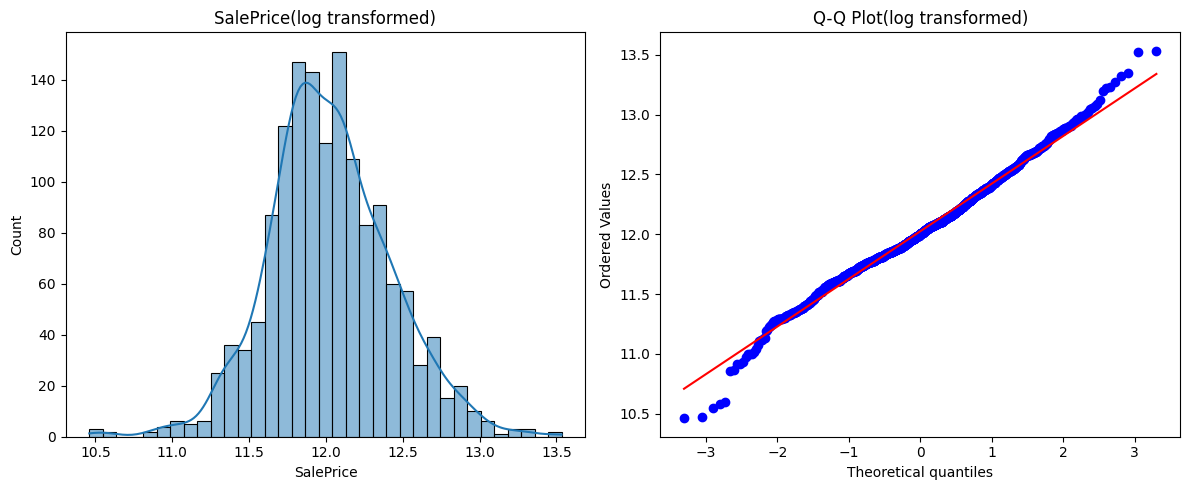

In [7]:
# log変換後の確認
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(np.log1p(train_df['SalePrice']), kde=True, ax=axes[0])
axes[0].set_title("SalePrice(log transformed)")

stats.probplot(np.log1p(train_df['SalePrice']), plot=axes[1])
axes[1].set_title("Q-Q Plot(log transformed)")

plt.tight_layout()
plt.show()


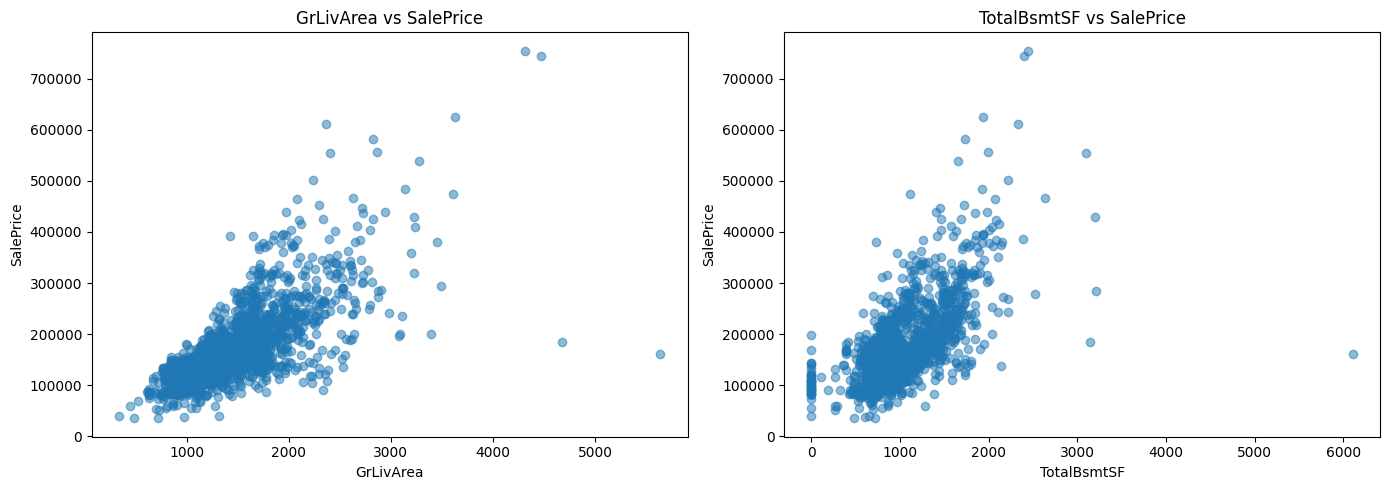

In [9]:
# GrLivAreaとSalePriceの関係を散布図で確認
# 面積が大きいほど価格が高いか、外れ値がないかを見る
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice')

#地下室の面積
axes[1].scatter(train_df['TotalBsmtSF'], train_df['SalePrice'], alpha=0.5)
axes[1].set_xlabel('TotalBsmtSF')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('TotalBsmtSF vs SalePrice')

plt.tight_layout()
plt.show()


GrLivAreaは右上に2点、面積がデカいのに価格が低い点が見えます。これが先ほどの外れ値2件です。

TotalBsmtSFはx軸の0付近に点が縦に並んでいます。地下室なしの家が一定数あることを示してます。右端に1点だけ離れた点もあり、これも外れ値候補です。

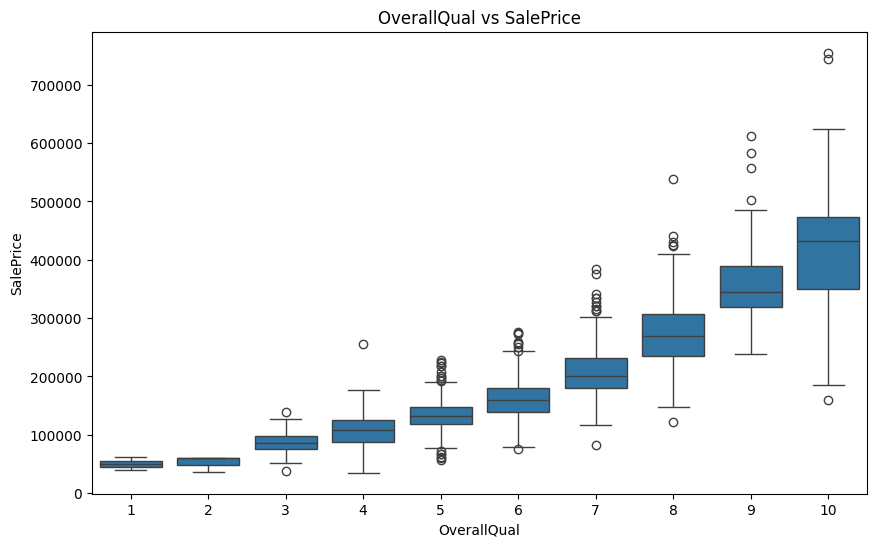

In [10]:
# OverallQualとSalePriceの関係をboxplotで確認
# 品質スコアが上がるほど価格も上がるかを見る
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df, ax=ax)
ax.set_title('OverallQual vs SalePrice')
plt.show()

品質スコアが1→10に上がるにつれてSalePriceも綺麗に上昇しています。OverallQualが特徴量として超重要なのはこれで視覚的に確認できました。

右上の2点はOverallQual=8なのに700000超え。外れ値候補ですが、品質8で高額なのは不自然ではないのでこれは残していいです。

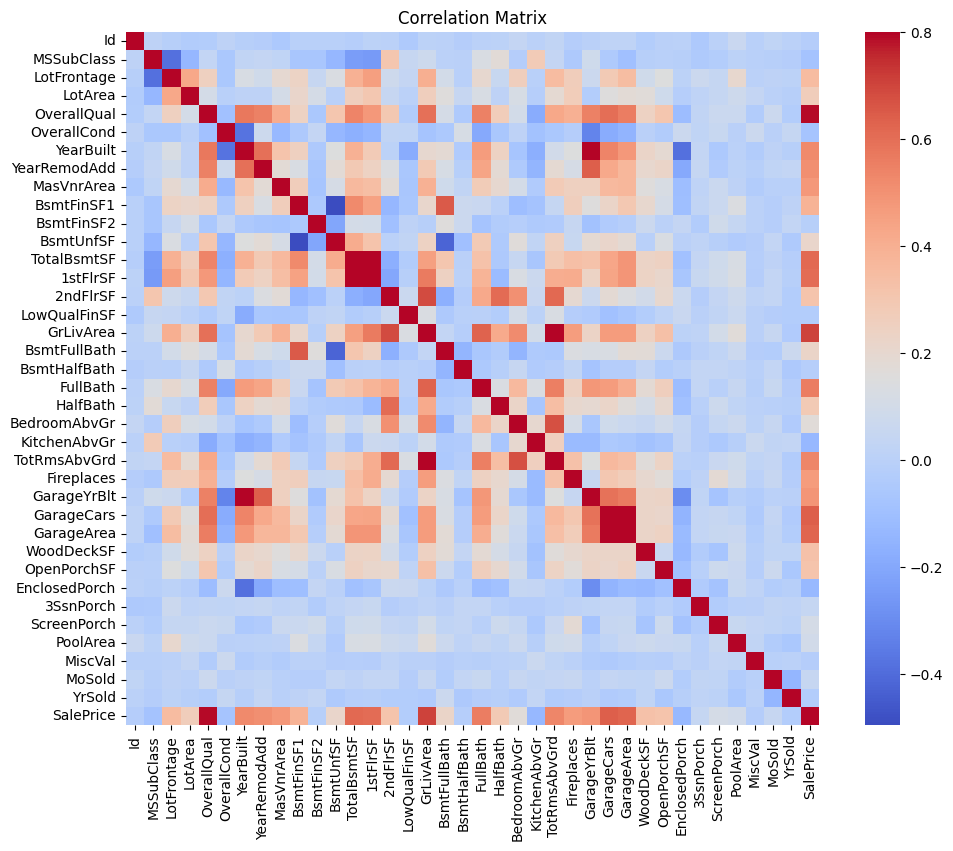

In [11]:
# 数値変数の相関行列をヒートマップで確認
# どの変数がSalePriceと強く相関しているかを一覧で見る
corrmat = train_df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=0.8, square=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


SalePriceの行（一番下）を横に見ると、赤が濃い変数がSalePriceと相関が強い変数です。

特に濃いのはOverallQual、GrLivArea、TotalBsmtSF、GarageCars、GarageAreaあたりです。特徴量エンジニアリングで既に使ってるものばかりなので、方向性は正しいです。

また対角線以外で赤い塊が2箇所あります。GarageCars×GarageAreaと、TotalBsmtSF×1stFlrSFです。
これは多重共線性、つまり同じ情報を持つ変数が重複しているサインです。

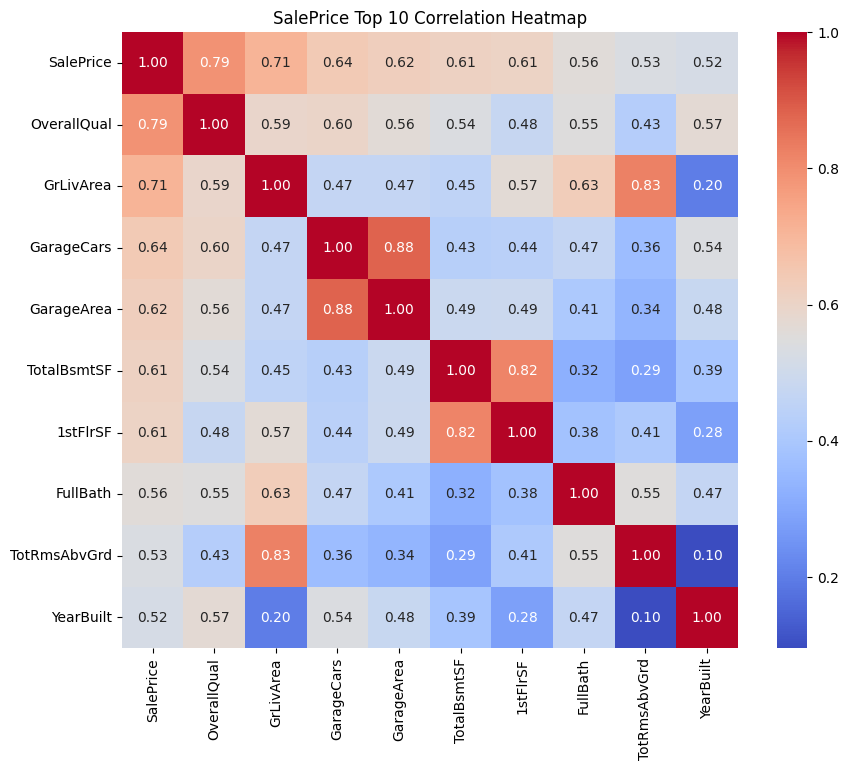

In [12]:
# SalePriceと相関が高い上位10変数に絞ったヒートマップ
# 重要変数同士の関係を細かく確認する
k = 10
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train_df[cols].values.T)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', square=True,
            yticklabels=cols.values, xticklabels=cols.values,
            cmap='coolwarm')
plt.title('SalePrice Top 10 Correlation Heatmap')
plt.show()


SalePriceとの相関まとめ（このヒートマップから）：


1位 OverallQual 0.79、

2位 GrLivArea 0.71、

3位 GarageCars 0.64、

4位 GarageArea 0.62、

5位 TotalBsmtSF 0.61、

6位 1stFlrSF 0.61


GarageCarsとGarageAreaは0.88の多重共線性なのに両方featuresに入ってます。

GarageScoreという掛け算特徴も作ってる。情報が重複しすぎてる可能性があります。


1stFlrSFはfeaturesに入っていないけど、SalePriceとの相関が0.61あります。TotalBsmtSFとは0.82の相関があるので追加しても意味は薄いですが、一応把握しておく価値があります。

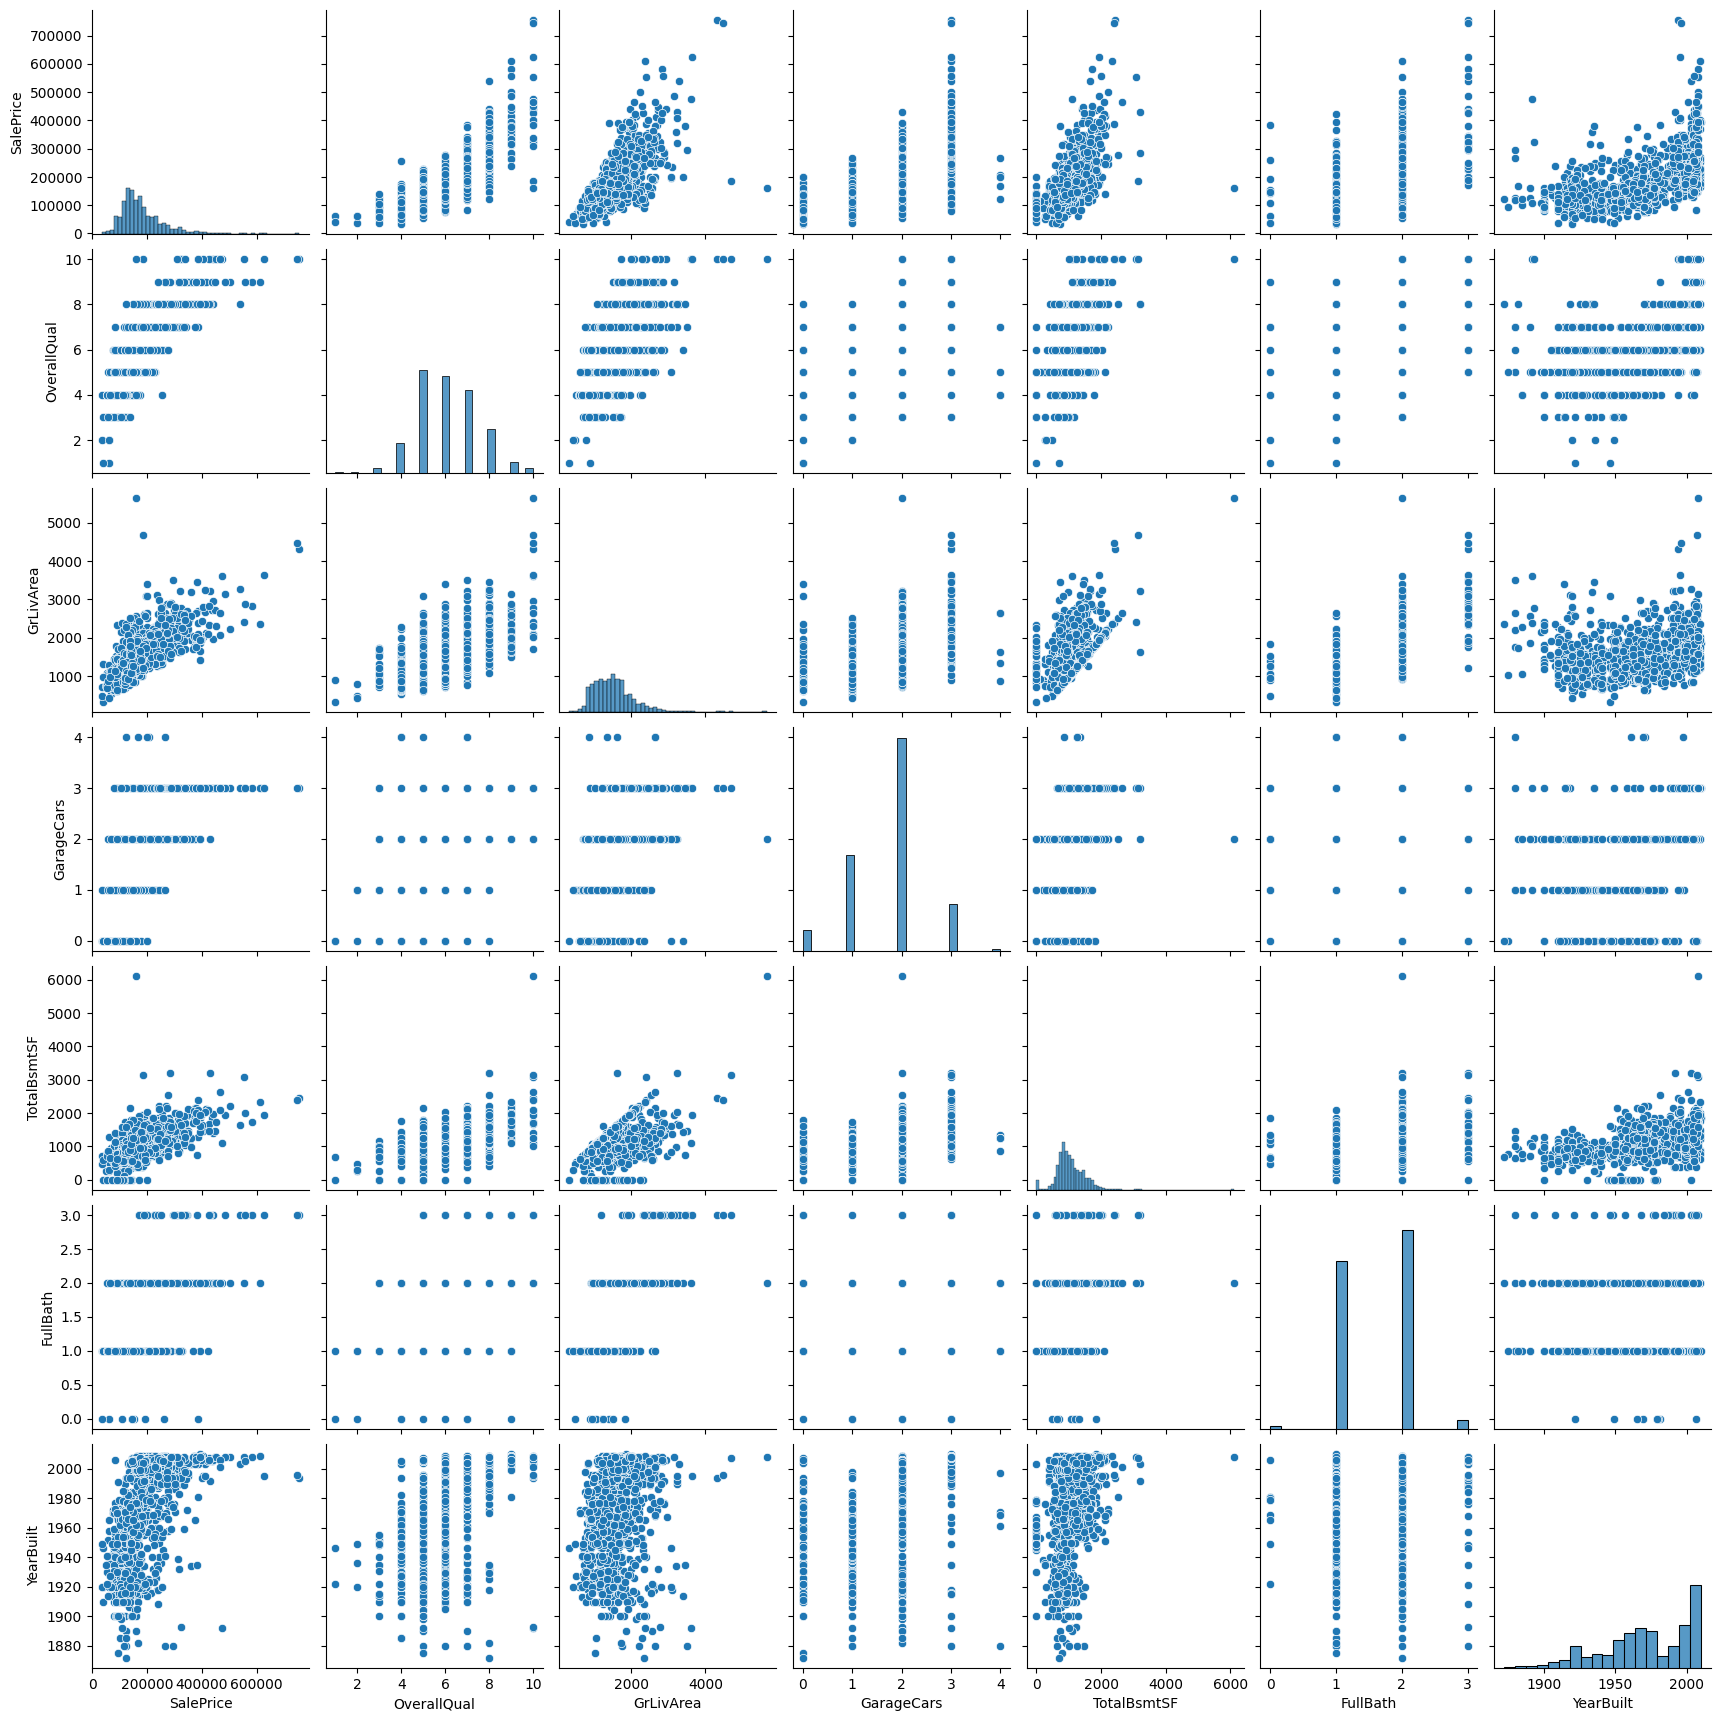

In [15]:
# 主要変数のpairplotで関係を一気に確認
# 変数間の線形関係・外れ値・分布を同時に見る
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_df[cols], height=2.5)
plt.show()


SalePriceとの関係として、

OverallQualは品質が上がるほど価格も上昇し最も強い正の相関がある。

GrLivAreaは概ね線形関係だが右下に外れ値が2件ある。

TotalBsmtSFも正の相関があるが0の家（地下室なし）が一定数存在する。

YearBuiltは新しいほど高い傾向があるが、新しくても安い物件や古くても高い物件が存在する。


多重共線性として、GrLivAreaとTotRmsAbvGrdが強く相関している。
GarageCarsとGarageAreaも同様。


外れ値として、GrLivAreaが4000超えで価格が低い2件が明確に確認できる。

In [16]:
# 数値変数の歪度を確認
# 歪度が高い変数はlog変換の候補
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
skew_vals = train_df[numeric_cols].skew().sort_values(ascending=False)

# 歪度0.75以上を要注意として表示
skew_high = skew_vals[skew_vals > 0.75]
print("歪度が0.75以上の変数：")
print(skew_high)


歪度が0.75以上の変数：
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64


読み取れること：
MiscVal 24.8、PoolArea 14.8、LotArea 12.2など、歪度が極端に高い変数が多数あります。これらは「ほとんどの家が0だけど、たまに極端に大きい値がある」変数です。

みなのfeaturesリストと照合すると、以下がlog変換候補として残っています。

	*	LotArea（歪度12.2）→ featuresに入ってる
	*	BsmtFinSF1（1.69）→ featuresに入ってる
	*	WoodDeckSF（1.54）→ featuresに入ってる
	*	OpenPorchSF（2.36）→ featuresに入ってる
	*	GrLivArea（1.37）→ 既にlog変換済み ✅



In [17]:
# 欠損値の数と割合を確認
# 欠損が多い変数は前処理で特別対応が必要
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_df = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
print(missing_df[missing_df['Total'] > 0])


              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageQual       81   5.547945
GarageFinish     81   5.547945
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageCond       81   5.547945
BsmtFinType2     38   2.602740
BsmtExposure     38   2.602740
BsmtCond         37   2.534247
BsmtQual         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


PoolQC、MiscFeature、Alley、FenceはEDAで情報量なしと判断。前処理ノートブックで削除を検討する。

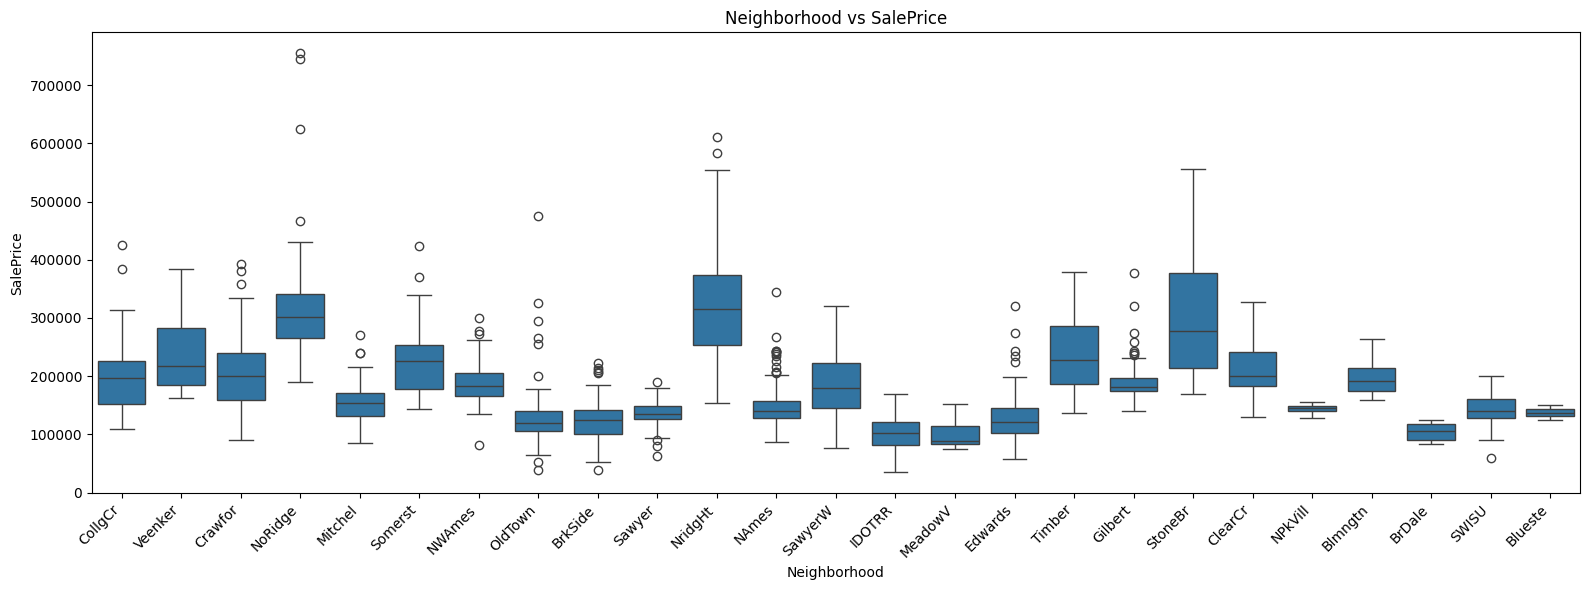

In [18]:
# NeighborhoodごとのSalePrice分布をboxplotで確認
# 地域によって価格帯が大きく異なるかを見る
plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train_df)
plt.xticks(rotation=45, ha='right')
plt.title('Neighborhood vs SalePrice')
plt.tight_layout()
plt.show()


NoRidge、NridgHt、StoneBrが明らかに価格が高いエリアです。

MeadowV、BrDaleが最も安いエリア。エリアによって価格帯が全然違うので、Neighborhood_TEが効いている理由がこれで視覚的に確認できました。